In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/my data set.csv'
data = pd.read_csv(file_path)
# Display the first few rows of the dataset
data.head()


,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1


In [10]:
# Check for missing values
data.isnull().sum()

# Display basic statistics about the chemicals
data.describe()


,CDPHId,CSFId,CompanyId,PrimaryCategoryId,SubCategoryId,CasId,ChemicalId,ChemicalCount
count,48686.000000,34841.000000,48685.000000,48685.000000,48685.000000,48685.000000,48685.000000,48685.000000
mean,7749.415725,14405.532878,257.471726,52.181986,65.866591,640.667413,12924.185909,1.226209
std,5210.643288,9658.760364,226.198680,22.167041,33.585953,161.477282,9364.846118,0.605309
min,2.000000,1.000000,4.000000,1.000000,3.000000,2.000000,0.000000,0.000000
25%,2931.000000,6315.000000,67.000000,44.000000,48.000000,656.000000,5219.000000,1.000000
50%,6677.500000,13353.000000,171.000000,44.000000,52.000000,656.000000,11457.000000,1.000000
75%,12763.000000,21134.000000,373.000000,59.000000,65.000000,656.000000,20893.000000,1.000000
max,16920.000000,60890.000000,1336.000000,111.000000,172.000000,1115.000000,66905.000000,8.000000


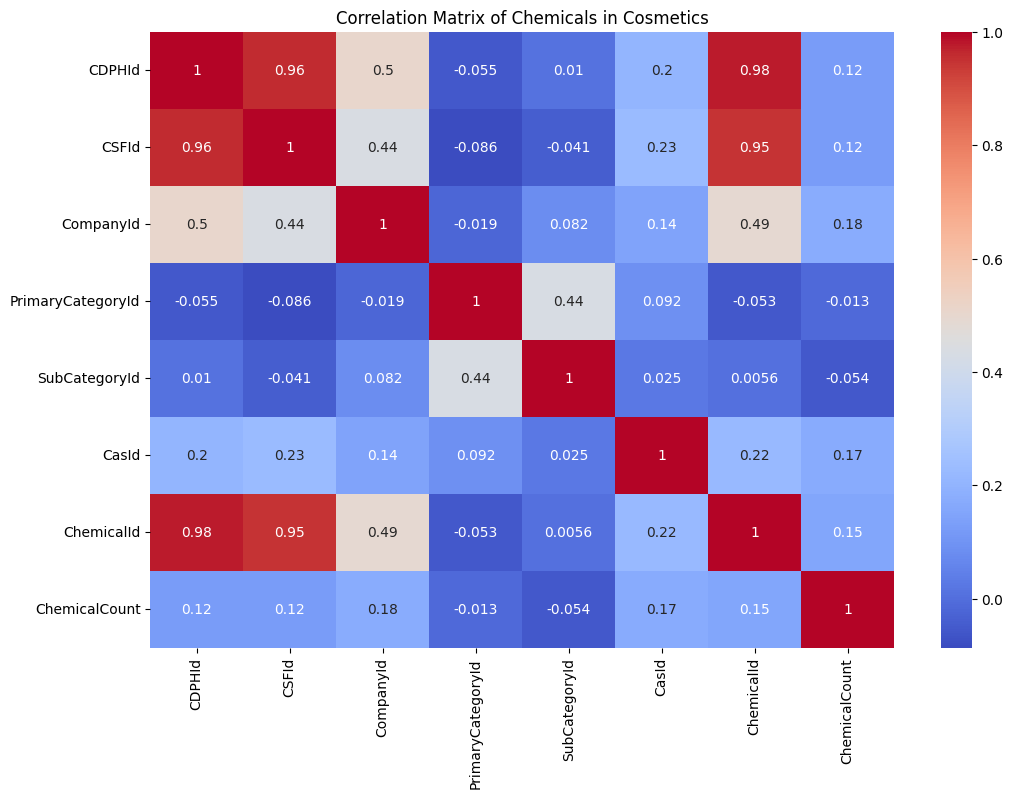

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/content/my data set.csv'
data = pd.read_csv(file_path)


data_numeric = data.select_dtypes(include=['number'])


correlation_matrix = data_numeric.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Chemicals in Cosmetics")
plt.show()


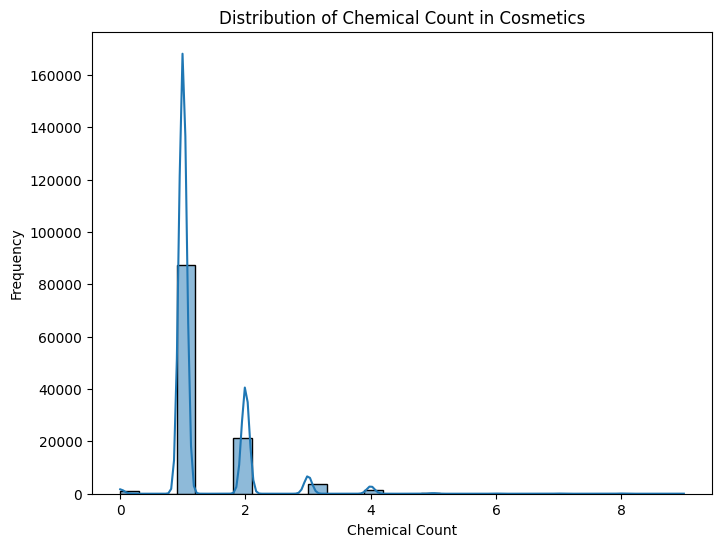

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.histplot(data['ChemicalCount'], kde=True, bins=30)
plt.title('Distribution of Chemical Count in Cosmetics')
plt.xlabel('Chemical Count')
plt.ylabel('Frequency')
plt.show()


In [24]:
# Detect harmful chemicals
harmful_chemicals = ['Titanium dioxide', 'Coal tar', 'Formaldehyde', 'Paraben', 'Phthalate', 'Lead', 'Mercury', 'Toluene']


data['is_harmful'] = data['ChemicalName'].str.lower().apply(
    lambda x: any(harm.lower() in x for harm in harmful_chemicals)
)

harmful_counts = data['is_harmful'].value_counts().rename(index={True: 'Harmful', False: 'Not Harmful'})

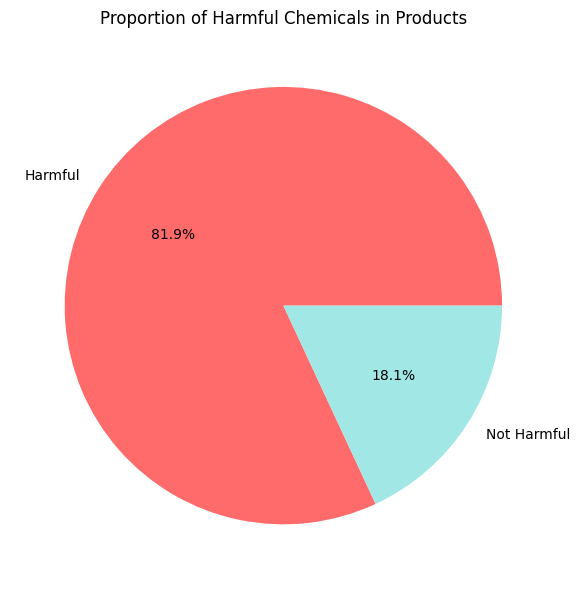

In [25]:
plt.figure(figsize=(6, 6))
harmful_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#FF6B6B', '#A0E7E5'])
plt.title('Proportion of Harmful Chemicals in Products')
plt.ylabel('')
plt.tight_layout()
plt.show()

<ipython-input-27-e286a29bb288>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=harmful_by_category.index, x=harmful_by_category.values, palette='Reds_r')


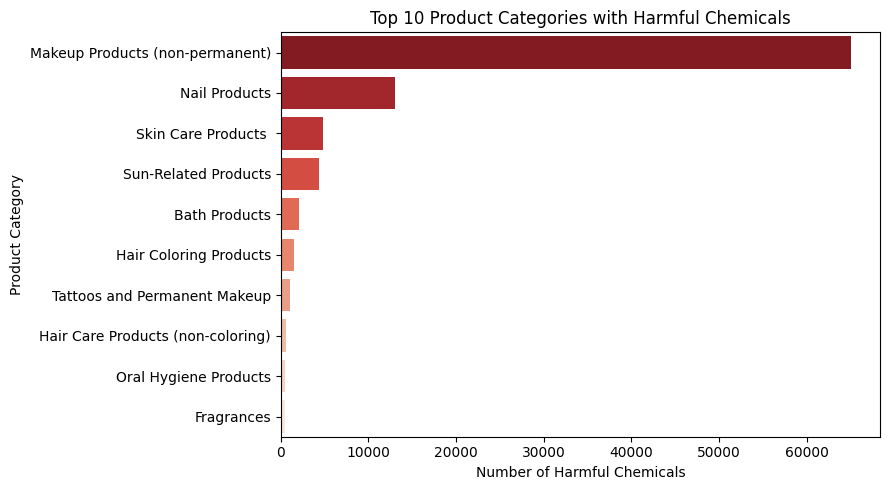

In [27]:
harmful_by_category = data[data['is_harmful']].groupby('PrimaryCategory')['ChemicalName'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(y=harmful_by_category.index, x=harmful_by_category.values, palette='Reds_r')
plt.title('Top 10 Product Categories with Harmful Chemicals')
plt.xlabel('Number of Harmful Chemicals')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

<ipython-input-29-893bb6082217>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=harmful_by_brand.index, x=harmful_by_brand.values, palette='Purples_r')


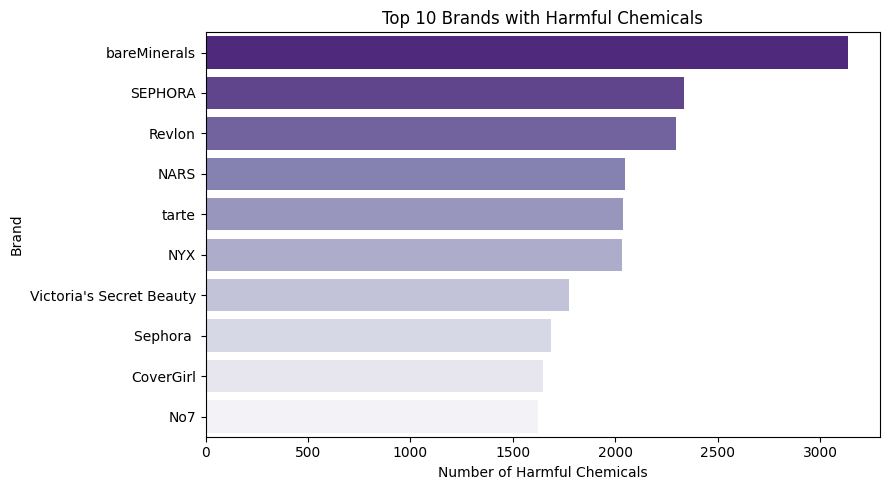

In [29]:
harmful_by_brand = data[data['is_harmful']].groupby('BrandName')['ChemicalName'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(y=harmful_by_brand.index, x=harmful_by_brand.values, palette='Purples_r')
plt.title('Top 10 Brands with Harmful Chemicals')
plt.xlabel('Number of Harmful Chemicals')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()


In [30]:
# Brand-level summary
brand_summary = data.groupby('BrandName')['is_harmful'].agg(
    total_products='count',
    harmful_products='sum'
).reset_index()

brand_summary['has_harmful'] = brand_summary['harmful_products'] > 0

# Top 10 brands with most harmful products
top_brands = brand_summary.sort_values(by='harmful_products', ascending=False).head(10)
print(top_brands)


                     BrandName  total_products  harmful_products  has_harmful
2648              bareMinerals            3158              3136         True
1985                   SEPHORA            3394              2338         True
1929                    Revlon            2335              2299         True
1604                      NARS            2185              2050         True
2708                     tarte            2101              2039         True
1626                       NYX            3227              2031         True
2533  Victoria's Secret Beauty            2106              1773         True
2083                  Sephora             1767              1688         True
674                  CoverGirl            1711              1645         True
1688                       No7            1749              1622         True
